ESERCIZIO

Modifica il valore della variabile commitment_cost nel codice e avvia l'addestramento per tre scenari distinti:
c=0 (nessun impiego: l'encoder è libero di allontanardi dal dizionario)
c=3 (bilanciamento standard)
c=10 (impegno massimo): l'encoder è forzato a restare vicinissimo agli embedding attuali


--- ESPERIMENTO: commitment_cost = 0 ---
Epoca 1/5...
Epoca 2/5...
Epoca 3/5...
Epoca 4/5...
Epoca 5/5...


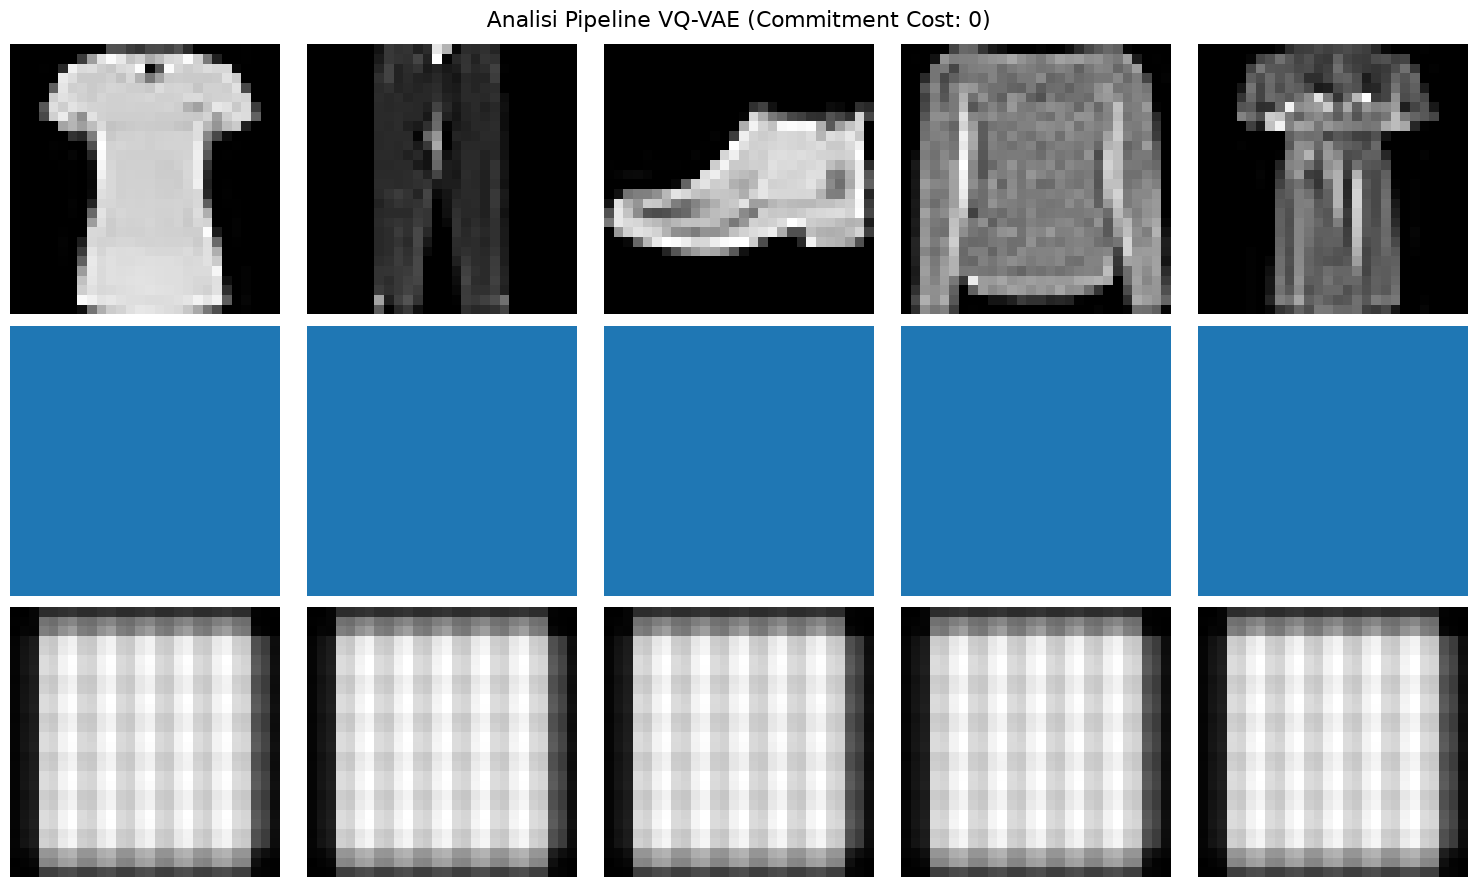


--- ESPERIMENTO: commitment_cost = 3 ---
Epoca 1/5...
Epoca 2/5...
Epoca 3/5...
Epoca 4/5...
Epoca 5/5...


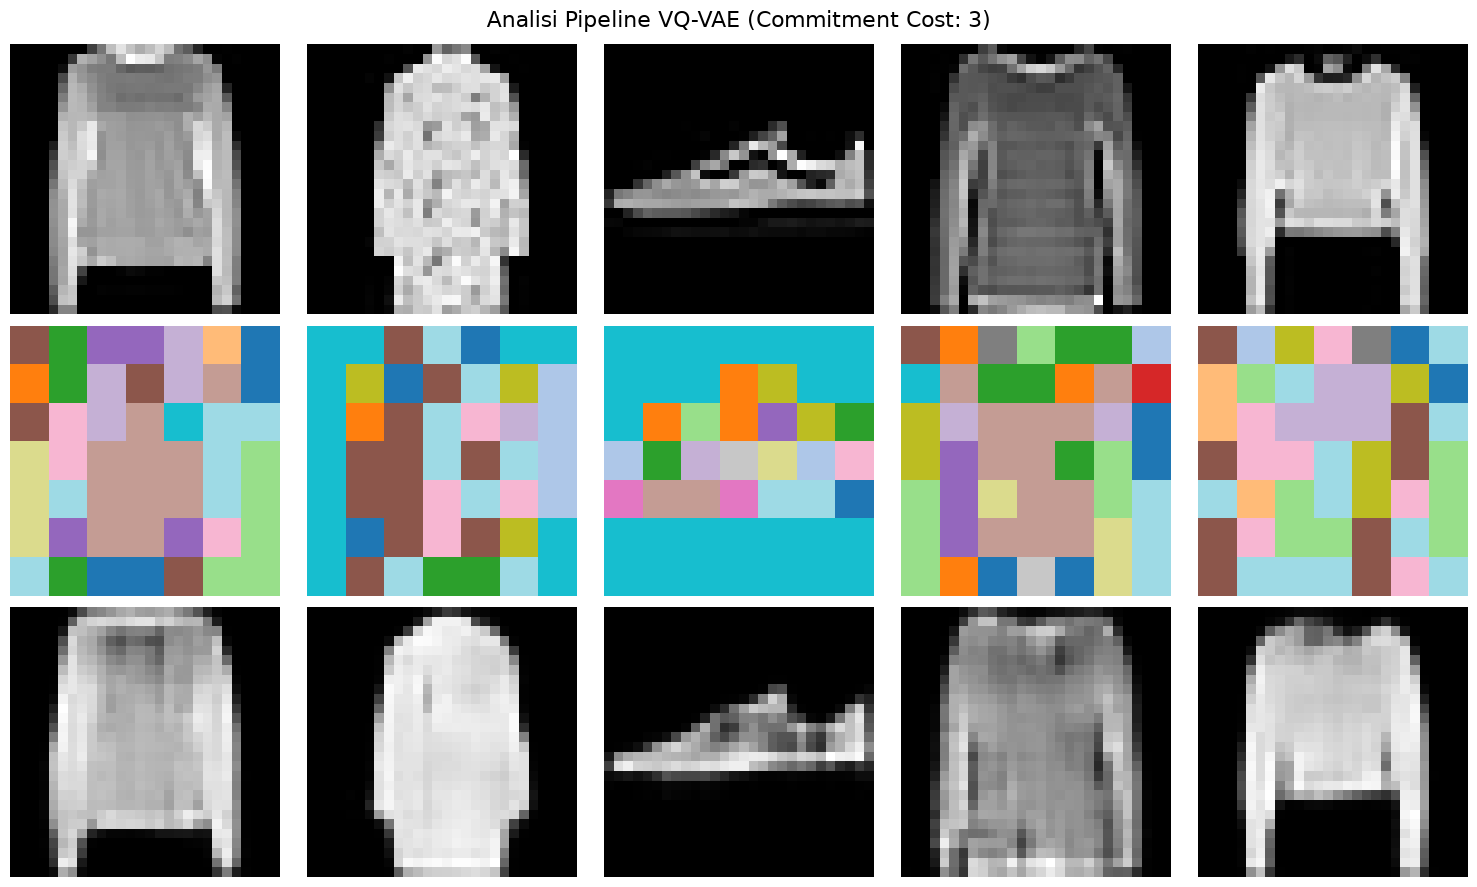


--- ESPERIMENTO: commitment_cost = 10 ---
Epoca 1/5...
Epoca 2/5...
Epoca 3/5...
Epoca 4/5...
Epoca 5/5...


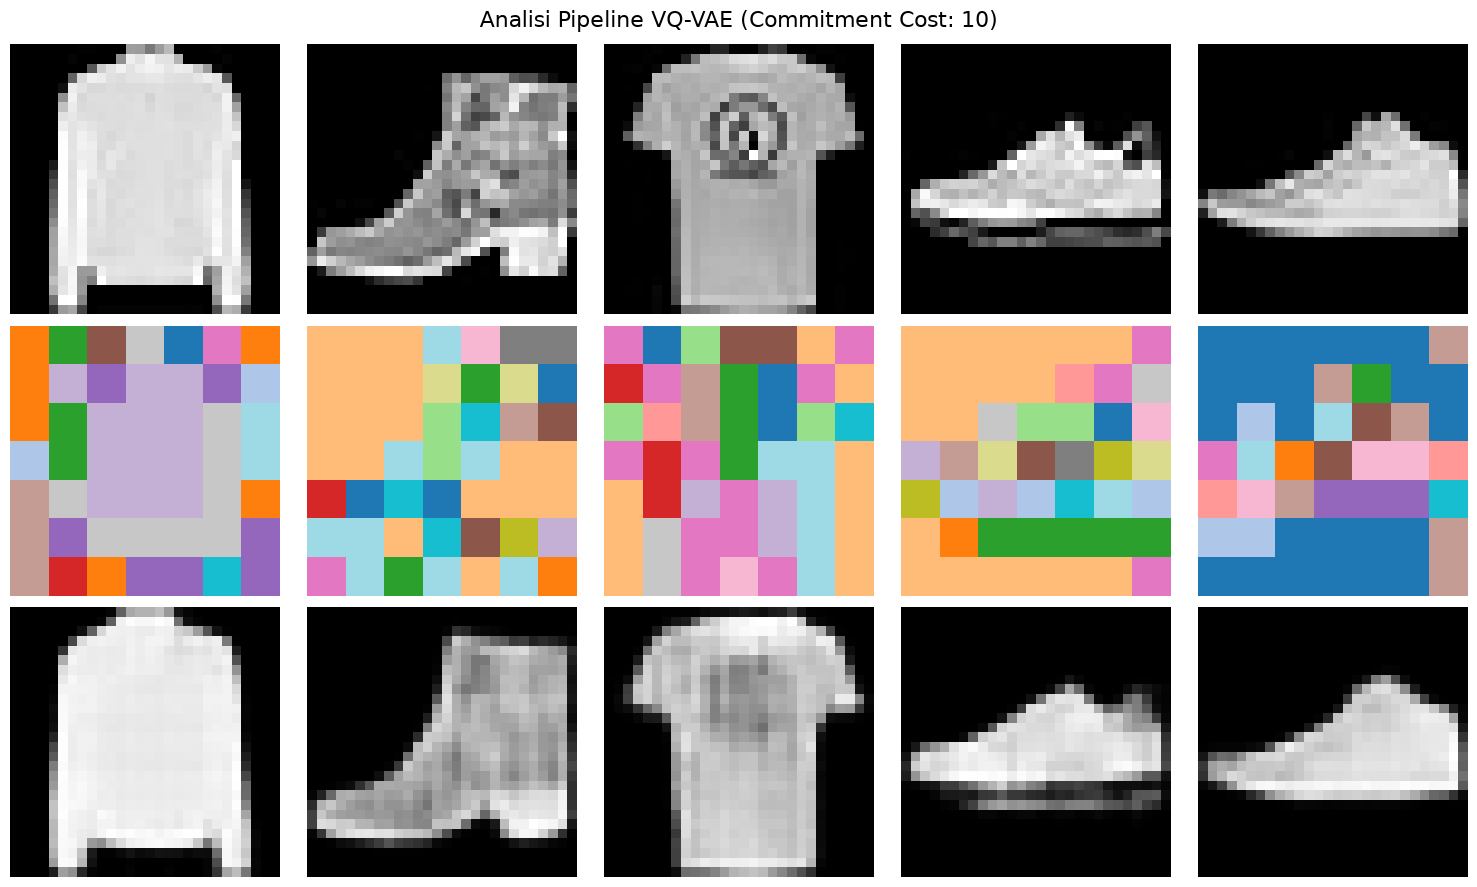

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# =============================================================================
# CONFIGURAZIONE GENERALE
# =============================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_embeddings = 128 
embedding_dim = 32 
batch_size = 128
epochs = 5 

transform = transforms.Compose([transforms.ToTensor()])
train_loader = DataLoader(
    datasets.FashionMNIST('.', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True
)

# =============================================================================
# CLASSI DEL MODELLO
# =============================================================================

class VectorQuantizer(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_cost):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings
        self.commitment_cost = commitment_cost
        self.codebook = nn.Embedding(self.num_embeddings, self.embedding_dim)
        self.codebook.weight.data.uniform_(-1/num_embeddings, 1/num_embeddings)

    def forward(self, inputs):
        inputs = inputs.permute(0, 2, 3, 1).contiguous()
        flat_input = inputs.view(-1, self.embedding_dim)
        distances = torch.cdist(flat_input, self.codebook.weight)
        encoding_indices = torch.argmin(distances, dim=1).unsqueeze(1)
        
        quantized = self.codebook(encoding_indices).view(inputs.shape)
        
        # Perdite: VQ per il codebook, Commitment per l'encoder
        vq_loss = F.mse_loss(quantized, inputs.detach())
        commitment_loss = F.mse_loss(quantized.detach(), inputs)
        loss = vq_loss + self.commitment_cost * commitment_loss
        
        # Straight-Through Estimator
        quantized = inputs + (quantized - inputs).detach()
        
        return quantized.permute(0, 3, 1, 2).contiguous(), loss

class VQVAE(nn.Module):
    def __init__(self, c_cost):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, embedding_dim, 1)
        )
        self.vq = VectorQuantizer(num_embeddings, embedding_dim, c_cost)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(embedding_dim, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 1, 1), nn.Sigmoid()
        )

    def forward(self, x):
        z_e = self.encoder(x)
        z_q, vq_loss = self.vq(z_e)
        x_recon = self.decoder(z_q)
        return x_recon, vq_loss

# =============================================================================
# FUNZIONE DI TRAINING E VISUALIZZAZIONE COMPLETA
# =============================================================================

def run_experiment(c_value):
    print(f"\n--- ESPERIMENTO: commitment_cost = {c_value} ---")
    model = VQVAE(c_value).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    model.train()
    for epoch in range(epochs):
        for data, _ in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            recon, vq_loss = model(data)
            loss = F.mse_loss(recon, data) + vq_loss
            loss.backward()
            optimizer.step()
        print(f"Epoca {epoch+1}/{epochs}...")

    visualize_full_pipeline(model, c_value)

def visualize_full_pipeline(model, c_value):
    model.eval()
    with torch.no_grad():
        images, _ = next(iter(train_loader))
        images = images.to(device)
        
        # Otteniamo ricostruzioni e indici
        z_e = model.encoder(images)
        z_e_flat = z_e.permute(0, 2, 3, 1).contiguous().view(-1, embedding_dim)
        distances = torch.cdist(z_e_flat, model.vq.codebook.weight)
        indices = torch.argmin(distances, dim=1).view(images.shape[0], 7, 7)
        recon, _ = model(images)

        # Plot a 3 righe
        fig, axes = plt.subplots(3, 5, figsize=(15, 9))
        fig.suptitle(f"Analisi Pipeline VQ-VAE (Commitment Cost: {c_value})", fontsize=16)
        
        for i in range(5):
            # 1. ORIGINALE
            axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
            axes[0, i].axis('off')
            if i == 0: axes[0, i].set_ylabel("Originale", size='large')
            
            # 2. MAPPA INDICI (Discretizzazione)
            axes[1, i].imshow(indices[i].cpu().numpy(), cmap='tab20')
            axes[1, i].axis('off')
            if i == 0: axes[1, i].set_ylabel("Indici Latenti", size='large')
            
            # 3. RICOSTRUZIONE
            axes[2, i].imshow(recon[i].cpu().squeeze(), cmap='gray')
            axes[2, i].axis('off')
            if i == 0: axes[2, i].set_ylabel("Ricostruito", size='large')
            
        plt.tight_layout()
        plt.show()

# =============================================================================
# ESECUZIONE
# =============================================================================

for c in [0, 3, 10]:
    run_experiment(c)